# Accuracy Analysis (Agentic Oracle)

Evaluates whether the system **worked correctly** end to end. The oracle makes
**two distinct decisions**, which this notebook analyzes separately:

1. **Validation / fraud detection** (Validator): is the session physically valid?
   Signal = `anomaly`. Legitimate → validated (`anomaly == none`), fraud → rejected.
2. **Credit issuance** (Governance): a credit is issued **if and only if** the
   session was validated **AND** its emissions are below the baseline. This is a
   deterministic formula, so a legitimate trip that emits *above* the baseline correctly
   receives **no** credit. For this reason "legitimate" does not imply "credit", and this
   is checked against the rule instead of being labeled as ground truth.

**Baseline:** 175 gCO₂/km (Programa MOVER, gasoline ICEV, Brazil).

**Data:** the synthetic benchmark runs in `../results/results_v2_1/`, one folder per run
(`rodada_1` … `rodada_5`, where *rodada* means run). Charts are saved to
`../results/results_v2_1/accuracy_analysis/`.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "font.family": "DejaVu Sans",
                     "axes.titleweight": "bold"})

RESULTS = Path("../results/results_v2_1")
OUT = RESULTS / "accuracy_analysis"
OUT.mkdir(parents=True, exist_ok=True)

# Baseline used in the analyzed run, must match config.BASELINE_CO2_G_PER_KM
BASELINE_G_PER_KM = 175.0

# Category and expected detector per scenario (numeric prefix of the file name)
EXPECTED = {
    "01": "legitimate", "02": "legitimate", "03": "legitimate", "04": "legitimate",
    "05": "aggressive",
    "06": "fraud", "07": "fraud", "08": "fraud", "09": "fraud",
    "10": "empty",
}
EXPECTED_ANOMALY = {
    "06": "impossible_speed", "07": "engine_off_motion",
    "08": "robotic_data",     "09": "temperature_hack",
}


## 1. Loading (all runs) and reference run

In [2]:
def load_all(results_dir=RESULTS, pattern="rodada_*"):
    rows = []
    for m in sorted(results_dir.glob(f"{pattern}/**/_manifest.json")):
        d = json.loads(m.read_text(encoding="utf-8"))
        run = m.relative_to(results_dir).parts[0]
        short = run.split("_run_")[0] if "_run_" in run else run
        for s in d.get("sessions", []):
            key = (s.get("scenario") or "")[:2]
            rows.append({
                "run": short, "vehicle": s.get("vehicle"), "trip": s.get("viagem"),
                "scenario": s.get("scenario"), "category": EXPECTED.get(key, "unknown"),
                "exp_anomaly": EXPECTED_ANOMALY.get(key),
                "status": s.get("status"), "decision": s.get("governance_decision"),
                "anomaly": s.get("anomaly"), "confidence": s.get("confidence"),
                "co2_g": s.get("total_co2_g"), "saved_g": s.get("co2_saved_g"),
                "distance_km": s.get("distance_km"), "credits_cct": s.get("credits_cct"),
            })
    return pd.DataFrame(rows)

df_all = load_all()
runs = sorted(df_all["run"].unique())
# A folder named rodada_unica (single run) is used as the reference when present
_single = [r for r in runs if "unica" in r.lower()]
ref = _single[0] if _single else runs[0]
df = df_all[df_all["run"] == ref].copy()
print(f"Available runs: {runs}")
print(f"Reference run: {ref}  ({len(df)} sessions)")

# Derived signals
df["validated"] = (df["status"] == "ok") & (df["anomaly"] == "none")
df["credited"] = (df["status"] == "ok") & (df["decision"] == "approved")
df["is_fraud"] = df["category"] == "fraud"
df.head()


Available runs: ['rodada_1', 'rodada_2', 'rodada_3', 'rodada_4', 'rodada_5']
Reference run: rodada_1  (80 sessions)


,run,vehicle,trip,scenario,category,exp_anomaly,status,decision,anomaly,confidence,co2_g,saved_g,distance_km,credits_cct,validated,credited,is_fraud
0,rodada_1,creta,1,01_viagem_perfeita,legitimate,None,ok,denied,none,65.0,1100.51,-127.86,5.558,0.000000,True,False,False
1,rodada_1,creta,1,02_eco_motorista,legitimate,None,ok,approved,none,65.0,660.31,1062.92,9.847,1.062916,True,True,False
2,rodada_1,creta,1,03_viagem_etanol,legitimate,None,ok,denied,none,65.0,1100.51,-127.86,5.558,0.000000,True,False,False
3,rodada_1,creta,1,04_falha_sensor_maf_mas_valido,legitimate,None,ok,denied,none,65.0,1100.51,-127.86,5.558,0.000000,True,False,False
4,rodada_1,creta,1,05_motorista_agressivo,aggressive,None,ok,denied,none,65.0,3690.22,-228.55,19.781,0.000000,True,False,False


## 2. Determinism across runs (justification for n = 1)

Decision, CO2 and credits are identical in the available runs.


In [3]:
ok_all = df_all[df_all["status"] == "ok"]
g = ok_all.groupby(["vehicle", "trip", "scenario"]).agg(
    decisions=("decision", lambda x: x.dropna().nunique()),
    co2_std=("co2_g", lambda x: x.dropna().std() or 0),
    cred_std=("credits_cct", lambda x: x.dropna().std() or 0),
)
div = g[(g["decisions"] > 1) | (g["co2_std"] > 1e-6) | (g["cred_std"] > 1e-9)]
if len(runs) == 1:
    print("[i] Only one run available, determinism is shown in the latency analysis.")
elif div.empty:
    print(f"[OK] Determinism confirmed in {len(runs)} runs: identical decision, CO2 and "
          "credits. One run is representative.")
else:
    print("[!] Divergences across runs:"); print(div)


[OK] Determinism confirmed in 5 runs: identical decision, CO2 and credits. One run is representative.


## 3. Validation / fraud detection

Binary problem: **fraud** (positive) vs. **legitimate** (negative, includes 01–05).
Predicted positive = session **rejected** by the validator (`anomaly != none`).
This section measures the ability to block fraudulent or inconsistent data,
regardless of credit issuance.


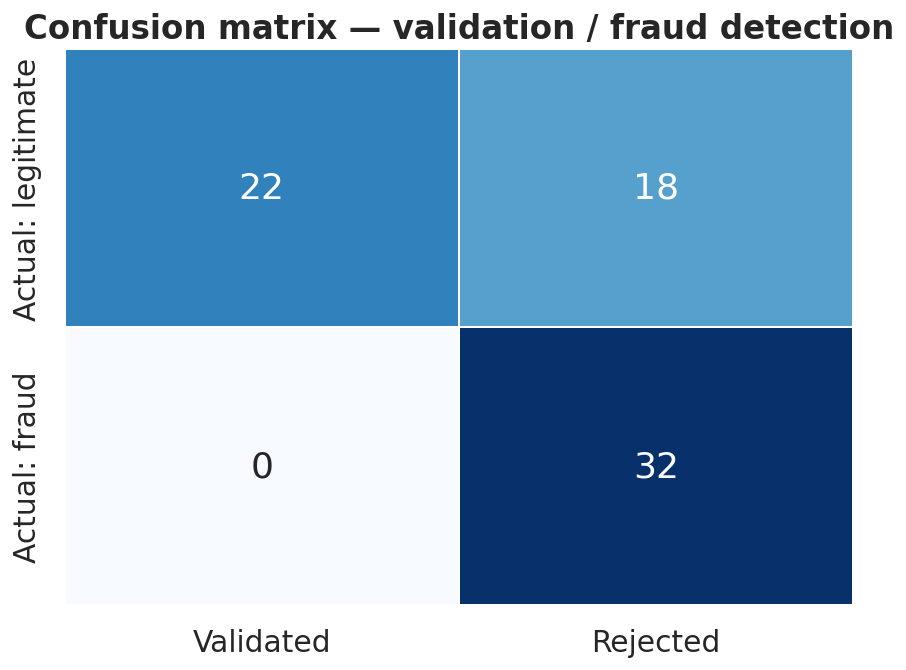

Accuracy    : 0.750
Precision   : 0.640
Recall      : 1.000  (sensitivity to fraud)
Specificity : 0.550
F1-score    : 0.780

Frauds that passed (FN): 0
Legitimate rejected (FP): 18  (see section 7, physically inconsistent data)


In [4]:
b = df[df["category"].isin(["legitimate", "aggressive", "fraud"])].copy()
b["rejected"] = ~b["validated"]

TP = int((b["is_fraud"] & b["rejected"]).sum())     # fraud correctly rejected
FN = int((b["is_fraud"] & ~b["rejected"]).sum())    # fraud that passed
FP = int((~b["is_fraud"] & b["rejected"]).sum())    # legitimate rejected
TN = int((~b["is_fraud"] & ~b["rejected"]).sum())   # legitimate validated

acc  = (TP + TN) / (TP + TN + FP + FN)
prec = TP / (TP + FP) if (TP + FP) else float("nan")
rec  = TP / (TP + FN) if (TP + FN) else float("nan")
spec = TN / (TN + FP) if (TN + FP) else float("nan")
f1   = 2 * prec * rec / (prec + rec) if prec + rec else float("nan")

cm = pd.DataFrame([[TN, FP], [FN, TP]],
                  index=["Actual: legitimate", "Actual: fraud"],
                  columns=["Validated", "Rejected"])
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=1,
            linecolor="white", annot_kws={"size": 20}, ax=ax)
ax.set_title("Confusion matrix — validation / fraud detection")
fig.tight_layout(); fig.savefig(OUT / "validation_confusion_matrix.png"); plt.show()

print(f"Accuracy    : {acc:.3f}")
print(f"Precision   : {prec:.3f}")
print(f"Recall      : {rec:.3f}  (sensitivity to fraud)")
print(f"Specificity : {spec:.3f}")
print(f"F1-score    : {f1:.3f}")
print(f"\nFrauds that passed (FN): {FN}")
print(f"Legitimate rejected (FP): {FP}  (see section 7, physically inconsistent data)")


## 4. Did the right detector fire?

Each fraud scenario has an expected physical detector. This checks whether the
identified anomaly matches the type of fraud.


Fraud scenario -> expected vs. detected detector:
                              scenario       exp_anomaly           anomaly  n
       06_fraude_velocidade_impossivel  impossible_speed  impossible_speed  8
07_fraude_motor_desligado_em_movimento engine_off_motion engine_off_motion  8
        08_fraude_bot_gerador_de_dados      robotic_data      robotic_data  8
 09_fraude_sensor_temperatura_hackeado  temperature_hack engine_off_motion  2
 09_fraude_sensor_temperatura_hackeado  temperature_hack  temperature_hack  6

Correct detector in 94% of the frauds (30/32)


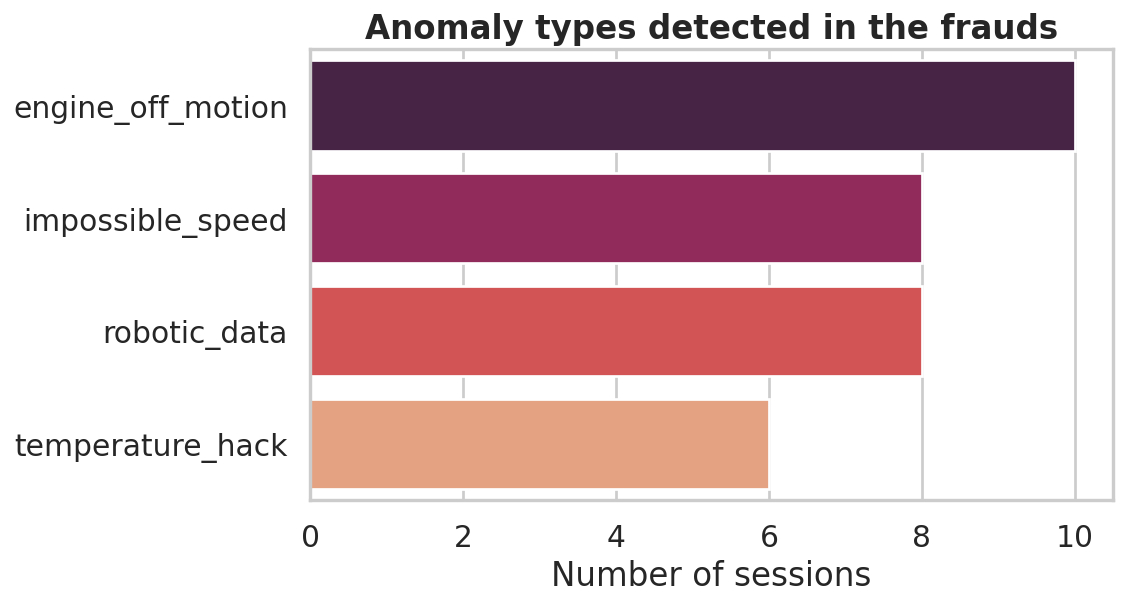

In [5]:
fr = df[df["category"] == "fraud"].copy()
fr["correct_detector"] = fr["anomaly"] == fr["exp_anomaly"]
tab = fr.groupby(["scenario", "exp_anomaly", "anomaly"]).size().reset_index(name="n")
print("Fraud scenario -> expected vs. detected detector:")
print(tab.to_string(index=False))
print(f"\nCorrect detector in {fr['correct_detector'].mean()*100:.0f}% of the frauds "
      f"({fr['correct_detector'].sum()}/{len(fr)})")

counts = fr["anomaly"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="rocket")
ax.set_xlabel("Number of sessions"); ax.set_ylabel("")
ax.set_title("Anomaly types detected in the frauds")
fig.tight_layout(); fig.savefig(OUT / "anomaly_detectors.png"); plt.show()


## 5. Credit issuance (governance)

A credit must be issued **if and only if** the session was validated **AND** its
emissions are below the baseline (175 gCO₂/km). The rule is recomputed independently
and compared with the recorded governance decision, which should give 100% consistency.

Note: legitimate trips that emit **above** the baseline correctly receive **no**
credit. This is not an error, it is the principle of the carbon credit.


Valid sessions evaluated: 72
Consistency of the recomputed rule vs. governance: 100.0%  (inconsistencies: 0)

Of 22 validated sessions: 14 below the baseline (with credit), 8 above (no credit, as expected).


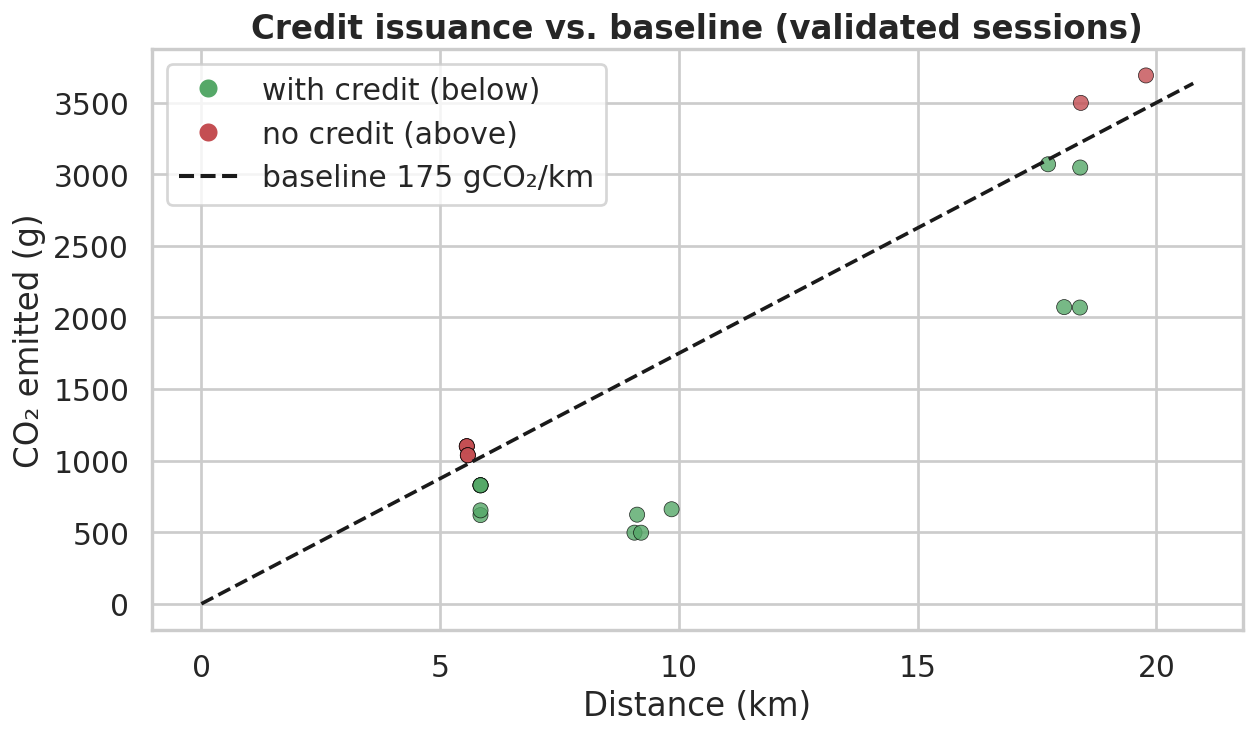

In [6]:
ok = df[df["status"] == "ok"].copy()
ok["gkm"] = np.where(ok["distance_km"] > 0, ok["co2_g"] / ok["distance_km"], np.nan)
# Expected rule (recomputed): credit iff validated AND emissions below the baseline
ok["expected_credit"] = ok["validated"] & (ok["co2_g"] < BASELINE_G_PER_KM * ok["distance_km"])
ok["consistent"] = ok["expected_credit"] == ok["credited"]

n_inconsistent = int((~ok["consistent"]).sum())
print(f"Valid sessions evaluated: {len(ok)}")
print(f"Consistency of the recomputed rule vs. governance: "
      f"{100*ok['consistent'].mean():.1f}%  (inconsistencies: {n_inconsistent})")
if n_inconsistent:
    print(ok[~ok["consistent"]][["vehicle","scenario","gkm","validated",
          "credited","expected_credit"]].to_string(index=False))

# Among the VALIDATED sessions, separate those with credit (below the baseline) from the others
val = ok[ok["validated"]]
below = int((val["credited"]).sum())
above  = int((~val["credited"]).sum())
print(f"\nOf {len(val)} validated sessions: {below} below the baseline (with credit), "
      f"{above} above (no credit, as expected).")

fig, ax = plt.subplots(figsize=(10, 6))
colors = val["credited"].map({True: "#55A868", False: "#C44E52"})
ax.scatter(val["distance_km"], val["co2_g"], c=colors, s=70, alpha=0.8,
           edgecolor="black", linewidth=0.4)
xs = np.linspace(0, val["distance_km"].max() * 1.05, 50)
ax.plot(xs, BASELINE_G_PER_KM * xs, "k--", lw=2,
        label=f"baseline {BASELINE_G_PER_KM:.0f} gCO₂/km")
ax.set_xlabel("Distance (km)"); ax.set_ylabel("CO₂ emitted (g)")
ax.set_title("Credit issuance vs. baseline (validated sessions)")
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#55A868", markersize=11, label="with credit (below)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#C44E52", markersize=11, label="no credit (above)"),
    Line2D([0],[0], ls="--", color="k", label=f"baseline {BASELINE_G_PER_KM:.0f} gCO₂/km"),
])
fig.tight_layout(); fig.savefig(OUT / "credit_vs_baseline.png"); plt.show()


## 6. Correctness of the credit values

For every session with credit, the value must follow `credits_CCT = CO2_saved_g / 1000`.


Sessions with credit: 14
Maximum error (issued vs formula): 4.33e-06 CCT
Mean error: 2.48e-06 CCT (rounding only)


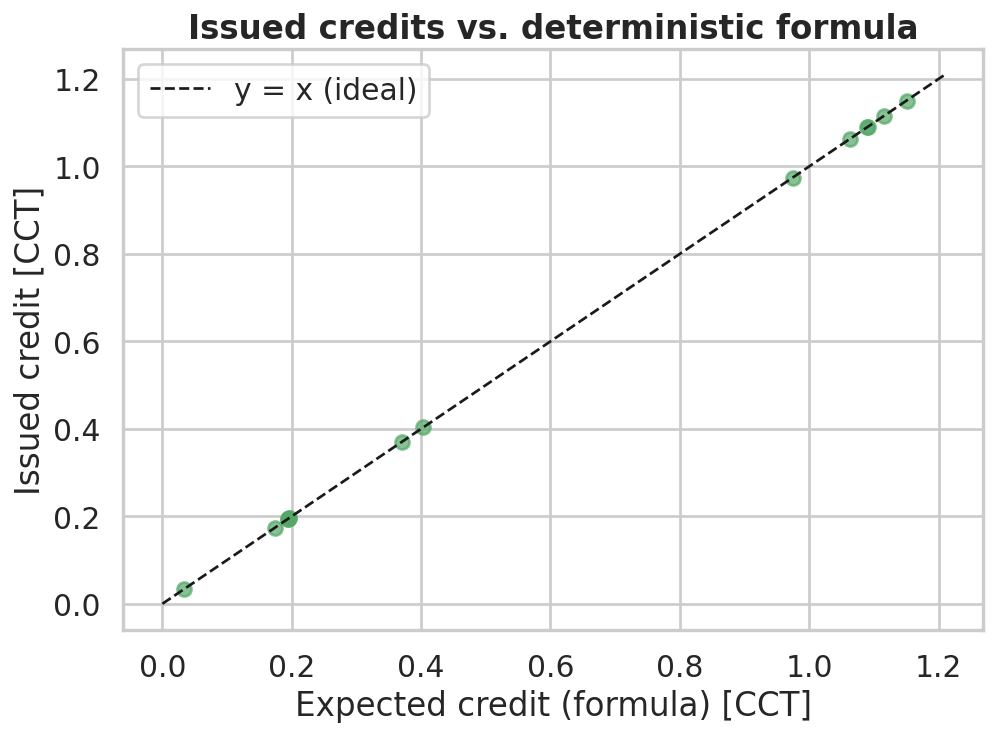

In [7]:
apr = df[df["credited"]].dropna(subset=["credits_cct", "saved_g"]).copy()
if apr.empty:
    print("No session received credit in this run.")
else:
    apr["formula_credit"] = apr["saved_g"] / 1000.0
    apr["abs_error"] = (apr["credits_cct"] - apr["formula_credit"]).abs()
    print(f"Sessions with credit: {len(apr)}")
    print(f"Maximum error (issued vs formula): {apr['abs_error'].max():.2e} CCT")
    print(f"Mean error: {apr['abs_error'].mean():.2e} CCT (rounding only)")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(apr["formula_credit"], apr["credits_cct"], s=60, alpha=0.7,
               color=sns.color_palette("deep")[2])
    lim = [0, apr["formula_credit"].max() * 1.05]
    ax.plot(lim, lim, "k--", lw=1.5, label="y = x (ideal)")
    ax.set_xlabel("Expected credit (formula) [CCT]")
    ax.set_ylabel("Issued credit [CCT]")
    ax.set_title("Issued credits vs. deterministic formula")
    ax.legend(); fig.tight_layout()
    fig.savefig(OUT / "credit_values.png"); plt.show()


## 7. Rejected legitimate cases (validation false positives)

Some legitimate sessions derived from real data are rejected by the validator. This
section separates **correct oracle behavior on problematic data** (zero CO2, motion
with the engine off) from what would be a logic failure.


In [8]:
fp = df[(df["category"].isin(["legitimate", "aggressive"])) & (~df["validated"]) & (df["status"] == "ok")]
if fp.empty:
    print("No legitimate session rejected by the validator.")
else:
    print(f"{len(fp)} legitimate sessions rejected by the validator:")
    print(fp[["vehicle", "trip", "scenario", "co2_g", "anomaly"]].to_string(index=False))
    print("\nBy reason:")
    print(fp["anomaly"].value_counts().to_string())
    print("\nInterpretation: correct rejections of physically inconsistent data "
          "(CO2 = 0 due to missing MAF/rpm, motion with the engine off), not a logic failure.")


18 legitimate sessions rejected by the validator:
 vehicle trip                       scenario  co2_g           anomaly
fastback    1             01_viagem_perfeita   0.00           too_low
fastback    1               02_eco_motorista   0.00           too_low
fastback    1               03_viagem_etanol   0.00           too_low
fastback    1 04_falha_sensor_maf_mas_valido   0.00           too_low
fastback    1         05_motorista_agressivo   0.00           too_low
fastback    2             01_viagem_perfeita   0.00           too_low
fastback    2               02_eco_motorista   0.00           too_low
fastback    2               03_viagem_etanol   0.00           too_low
fastback    2 04_falha_sensor_maf_mas_valido   0.00           too_low
fastback    2         05_motorista_agressivo   0.00           too_low
    polo    1             01_viagem_perfeita 992.36 engine_off_motion
    polo    1               02_eco_motorista 595.42 engine_off_motion
    polo    1               03_viagem_et

## 8. Accuracy summary

In [9]:
val_legit = df[df["category"].isin(["legitimate", "aggressive"])]["validated"].sum()
n_legit = int(df["category"].isin(["legitimate", "aggressive"]).sum())
print("=" * 62)
print(f"SUMMARY — ACCURACY (reference run: {ref})")
print("=" * 62)
print("VALIDATION / FRAUD DETECTION")
print(f"  Frauds detected (TP)       : {TP}/{TP+FN}  (recall {rec:.2f})")
print(f"  Frauds that passed (FN)    : {FN}" + ("  -> no fraud passed" if FN == 0 else ""))
print(f"  Legitimate validated       : {val_legit}/{n_legit}")
print(f"  Legitimate rejected (FP)   : {FP}  (physically inconsistent data, section 7)")
print(f"  Correct detector for fraud : {fr['correct_detector'].mean()*100:.0f}%")
print("CREDIT ISSUANCE")
print(f"  Rule/baseline consistency  : {100*ok['consistent'].mean():.1f}%")
print(f"  Validated with credit (<{BASELINE_G_PER_KM:.0f}): {below}")
print(f"  Validated without credit (>={BASELINE_G_PER_KM:.0f}): {above}  (as expected)")
if not apr.empty:
    print(f"  Max error in the credit value: {apr['abs_error'].max():.1e} CCT")
print("\nArtifacts saved to:", OUT.as_posix())


SUMMARY — ACCURACY (reference run: rodada_1)
VALIDATION / FRAUD DETECTION
  Frauds detected (TP)       : 32/32  (recall 1.00)
  Frauds that passed (FN)    : 0  -> no fraud passed
  Legitimate validated       : 22/40
  Legitimate rejected (FP)   : 18  (physically inconsistent data, section 7)
  Correct detector for fraud : 94%
CREDIT ISSUANCE
  Rule/baseline consistency  : 100.0%
  Validated with credit (<175): 14
  Validated without credit (>=175): 8  (as expected)
  Max error in the credit value: 4.3e-06 CCT

Artifacts saved to: ../results/results_v2_1/accuracy_analysis
